# SIRS model prototype

I'm learning how to make new models in starsim, toward a continuous correlate of immunity model. 

To start, I just tried to combine the SIR and SIS models to make an SIRS. 

Initializing sim "Sim 0" with 5000 agents
Initializing sim "Sim 1" with 5000 agents
  Running "Sim 1": 2000.0 ( 0/51) (0.00 s)  ———————————————————— 2%

  Running "Sim 0": 2010.0 (10/51) (0.03 s)  ••••———————————————— 22%

  Running "Sim 0": 2020.0 (20/51) (0.06 s)  ••••••••———————————— 41%
  Running "Sim 1": 2020.0 (20/51) (0.06 s)  ••••••••———————————— 41%
  Running "Sim 0": 2030.0 (30/51) (0.09 s)  ••••••••••••———————— 61%
  Running "Sim 1": 2030.0 (30/51) (0.09 s)  ••••••••••••———————— 61%
  Running "Sim 0": 2040.0 (40/51) (0.11 s)  ••••••••••••••••———— 80%
  Running "Sim 1": 2040.0 (40/51) (0.12 s)  ••••••••••••••••———— 80%
  Running "Sim 0": 2050.0 (50/51) (0.13 s)  •••••••••••••••••••• 100%

  Running "Sim 1": 2050.0 (50/51) (0.14 s)  •••••••••••••••••••• 100%

Elapsed time: 0.256 s
Figure(933.333x700)


/Users/famulare/git/famulare/starsim/starsim/run.py:359: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


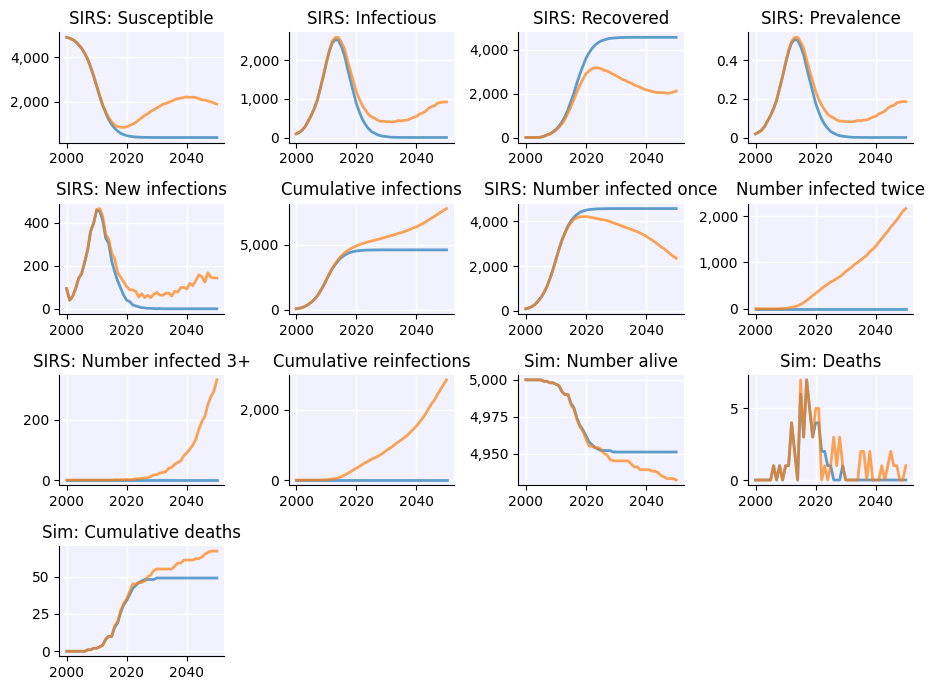

In [28]:
import starsim as ss

people = ss.People(n_agents=5_000)
network = ss.RandomNet(pars=dict(n_contacts=10))

# first, default SIR as a comparator
sir = ss.SIR(init_prev=0.01, beta=0.05)
sim_sir = ss.Sim(diseases=sir, people=people, networks=network)

# SIRS with zero waning, which should be a stochastic match to the first
sirs_w0 = ss.SIRS(init_prev=0.01, beta=0.05, waning=ss.expon(scale=ss.dur(1E10)))
sim_sirs_w0 = ss.Sim(diseases=sirs_w0, people=people, networks=network)

# SIRS with waning, which should be a stochastic match to the first
sirs = ss.SIRS(init_prev=0.01, beta=0.05, waning=ss.expon(scale=ss.dur(20)))
sim_sirs= ss.Sim(diseases=sirs, people=people, networks=network)

# msim = ss.MultiSim([sim_sir, sim_sirs_w0,sim_sirs]).run()
# msim.plot() 
# I think this has a sc.mergedicts bug! Enters at https://vscode.dev/github/famulare/starsim/blob/tutorials/starsim/run.py#L355 I think (?)
# dicts with different number of channels only get aligned by first sim, and names aren't used in matching

msim = ss.MultiSim([sim_sirs_w0,sim_sirs]).run()
msim.plot() 
